In [1]:
import argparse, json, math, re
import matplotlib.pyplot as plt
import sys
import copy
import numpy as np
from pathlib import Path
from typing import Iterable, Dict, Any, Optional, Callable

In [2]:
def load_json_dicts(
    folder: str | Path,
    *,
    include_glob: str = "*.json",          # e.g., "task_metrics_*.json"
    only_names: Optional[Iterable[str]] = None,  # exact filenames to keep (with or without .json)
    exclude_regex: Optional[str] = None,   # skip files whose name matches this regex
    limit: Optional[int] = None,           # load at most N files after sorting
    sort_by: str = "name",                 # "name" or "mtime"
    reverse: bool = False,                 # True -> descending (e.g., newest first)
    content_filter: Optional[Callable[[Path, Dict[str, Any]], bool]] = None,  # keep file if this returns True
) -> Dict[Path, Dict[str, Any]]:
    """
    Returns {path: dict} for a selected subset of JSON files in `folder`.
    """
    folder = Path(folder)

    # 1) discover candidates (recursive)
    files = list(folder.rglob(include_glob))

    # 2) optional explicit whitelist
    if only_names:
        name_set = {str(n).lower().removesuffix(".json") for n in only_names}
        files = [p for p in files if p.stem.lower() in name_set or p.name.lower() in name_set]

    # 3) optional exclude by regex on filename
    if exclude_regex:
        rx = re.compile(exclude_regex)
        files = [p for p in files if not rx.search(p.name)]

    # 4) sort
    if sort_by == "mtime":
        files.sort(key=lambda p: p.stat().st_mtime, reverse=reverse)
    else:
        files.sort(key=lambda p: p.name, reverse=reverse)

    # 5) load (with optional content-based filtering)
    out: Dict[Path, Dict[str, Any]] = {}
    for p in files:
        try:
            with p.open("r", encoding="utf-8") as f:
                data = json.load(f)  # each file has one dict
            if content_filter and not content_filter(p, data):
                continue
            out[p] = data
            if limit and len(out) >= limit:
                break
        except Exception as e:
            print(f"[WARN] Skipping {p} ({e})")
    return out

In [3]:
!pwd

/home/cloaked04/projects/predicators/predicators/experiments_pratyush/combined_framework_exp


In [4]:
exp1_hadd_data = load_json_dicts("/home/cloaked04/projects/predicators/predicators/experiments_pratyush/combined_framework_exp/Execution_time/eucledian_distance/hadd", include_glob="task_metrics_*.json", limit=80)

In [5]:
exp1_hadd_planning_time = []

for item in exp1_hadd_data.values():
    instance_planning_time = item['symbolic_planning_time']
    exp1_hadd_planning_time.append(instance_planning_time)

In [15]:
exp1_haddgeometric_data = load_json_dicts("/home/cloaked04/projects/predicators/predicators/experiments_pratyush/combined_framework_exp/Execution_time/eucledian_distance/haddgeometric", include_glob="task_metrics_*.json", limit=90)

In [16]:
exp1_haddgeometric_planning_time = []

for item in exp1_haddgeometric_data.values():
    instance_planning_time = item['symbolic_planning_time']
    exp1_haddgeometric_planning_time.append(instance_planning_time)

In [17]:
exp1_lmcut_data = load_json_dicts("/home/cloaked04/projects/predicators/predicators/experiments_pratyush/combined_framework_exp/Execution_time/eucledian_distance/lmcut", include_glob="task_metrics_*.json", limit=80)

In [18]:
exp1_lmcut_planning_time = []

for item in exp1_lmcut_data.values():
    instance_planning_time = item['symbolic_planning_time']
    exp1_lmcut_planning_time.append(instance_planning_time)

In [19]:
exp1_hadd_execution_time = []

for item in exp1_hadd_data.values():
    instance_execution_time = item['execution_times']
    # exp1_hadd_execution_time.append(instance_planning_time)
    # print(f"Execution time: {instance_execution_time}")
    # print("-------------------------------------------")
    full_exec_time = 0
    for action in instance_execution_time.values():
        full_exec_time+=action[1]
    exp1_hadd_execution_time.append(full_exec_time)

In [20]:
exp1_haddgeometric_execution_time = []

for item in exp1_haddgeometric_data.values():
    instance_execution_time = item['execution_times']
    # exp1_haddgeometric_planning_time.append(instance_planning_time)
    # print(f"Execution time: {instance_execution_time}")
    # print("-------------------------------------------")
    full_exec_time = 0
    for action in instance_execution_time.values():
        full_exec_time+=action[1]
    exp1_haddgeometric_execution_time.append(full_exec_time)

In [12]:
exp1_lmcut_execution_time = []

for item in exp1_lmcut_data.values():
    instance_execution_time = item['execution_times']
    # exp1_haddgeometric_planning_time.append(instance_planning_time)
    # print(f"Execution time: {instance_execution_time}")
    # print("-------------------------------------------")
    full_exec_time = 0
    for action in instance_execution_time.values():
        full_exec_time+=action[1]
    exp1_lmcut_execution_time.append(full_exec_time)

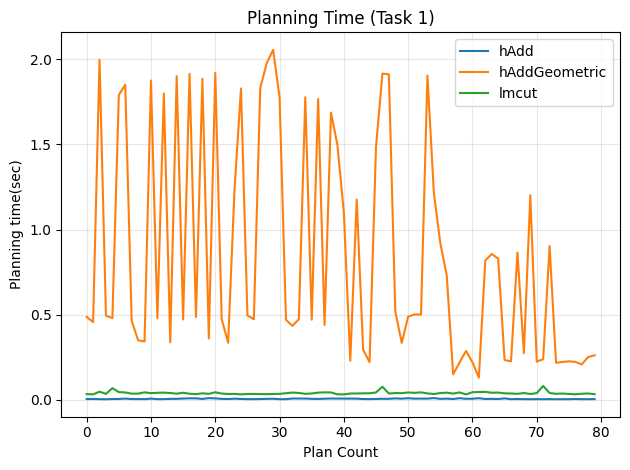

In [13]:
plt.figure()
plt.plot(exp1_hadd_planning_time, label='hAdd')
plt.plot(exp1_haddgeometric_planning_time, label='hAddGeometric')
plt.plot(exp1_lmcut_planning_time, label='lmcut')
plt.xlabel('Plan Count')
plt.ylabel('Planning time(sec)')
plt.title('Planning Time (Task 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

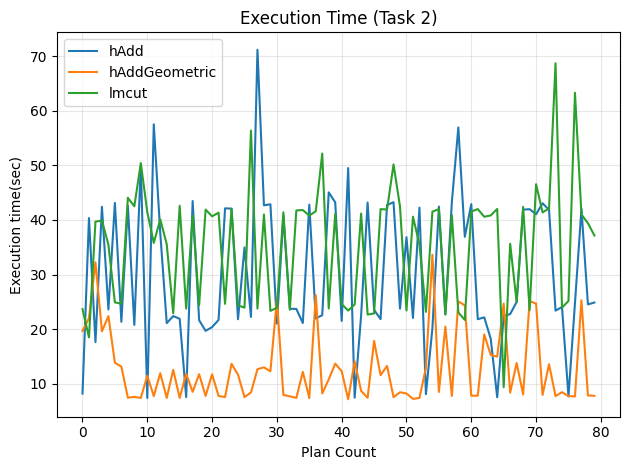

In [14]:
plt.figure()
plt.plot(exp1_hadd_execution_time, label='hAdd')
plt.plot(exp1_haddgeometric_execution_time, label='hAddGeometric')
plt.plot(exp1_lmcut_execution_time, label='lmcut')
plt.xlabel('Plan Count')
plt.ylabel('Execution time(sec)')
plt.title('Execution Time (Task 2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
exp2_hadd_data = load_json_dicts("/home/cloaked04/projects/predicators/predicators/experiments_pratyush/combined_framework_exp/Execution_time/sequential/hadd", include_glob="task_metrics_*.json", limit=80)
exp2_haddgeometric_data = load_json_dicts("/home/cloaked04/projects/predicators/predicators/experiments_pratyush/combined_framework_exp/Execution_time/sequential/haddgeometric", include_glob="task_metrics_*.json", limit=80)
exp2_lmcut_data = load_json_dicts("/home/cloaked04/projects/predicators/predicators/experiments_pratyush/combined_framework_exp/Execution_time/sequential/lmcut", include_glob="task_metrics_*.json", limit=80)

In [78]:
exp2_hadd_planning_time = []

for item in exp2_hadd_data.values():
    instance_planning_time = item['symbolic_planning_time']
    exp2_hadd_planning_time.append(instance_planning_time)
    
exp2_haddgeometric_planning_time = []

for item in exp2_haddgeometric_data.values():
    instance_planning_time = item['symbolic_planning_time']
    exp2_haddgeometric_planning_time.append(instance_planning_time)

exp2_lmcut_planning_time = []

for item in exp1_lmcut_data.values():
    instance_planning_time = item['symbolic_planning_time']
    exp2_lmcut_planning_time.append(instance_planning_time)

exp2_hadd_execution_time = []

for item in exp1_hadd_data.values():
    instance_execution_time = item['execution_times']
    # exp1_hadd_execution_time.append(instance_planning_time)
    # print(f"Execution time: {instance_execution_time}")
    # print("-------------------------------------------")
    full_exec_time = 0
    for action in instance_execution_time.values():
        full_exec_time+=action[1]
    exp2_hadd_execution_time.append(full_exec_time)

exp2_haddgeometric_execution_time = []

for item in exp2_haddgeometric_data.values():
    instance_execution_time = item['execution_times']
    # exp1_haddgeometric_planning_time.append(instance_planning_time)
    # print(f"Execution time: {instance_execution_time}")
    # print("-------------------------------------------")
    full_exec_time = 0
    for action in instance_execution_time.values():
        full_exec_time+=action[1]
    exp2_haddgeometric_execution_time.append(full_exec_time)

exp2_lmcut_execution_time = []

for item in exp2_lmcut_data.values():
    instance_execution_time = item['execution_times']
    # exp1_haddgeometric_planning_time.append(instance_planning_time)
    # print(f"Execution time: {instance_execution_time}")
    # print("-------------------------------------------")
    full_exec_time = 0
    for action in instance_execution_time.values():
        full_exec_time+=action[1]
    exp2_lmcut_execution_time.append(full_exec_time)

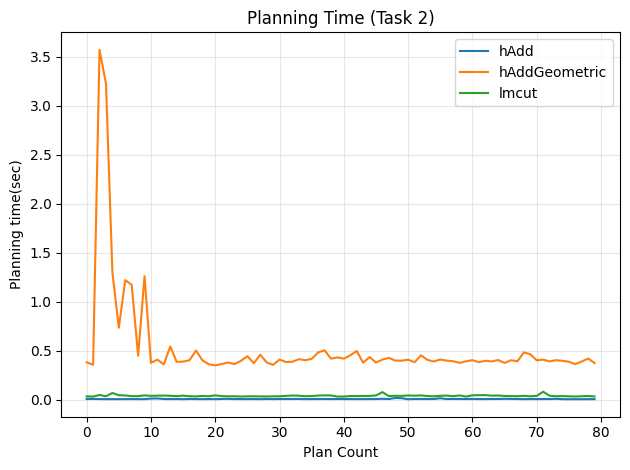

In [81]:
plt.figure()
plt.plot(exp2_hadd_planning_time, label='hAdd')
plt.plot(exp2_haddgeometric_planning_time, label='hAddGeometric')
plt.plot(exp2_lmcut_planning_time, label='lmcut')
plt.xlabel('Plan Count')
plt.ylabel('Planning time(sec)')
plt.title('Planning Time (Task 2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

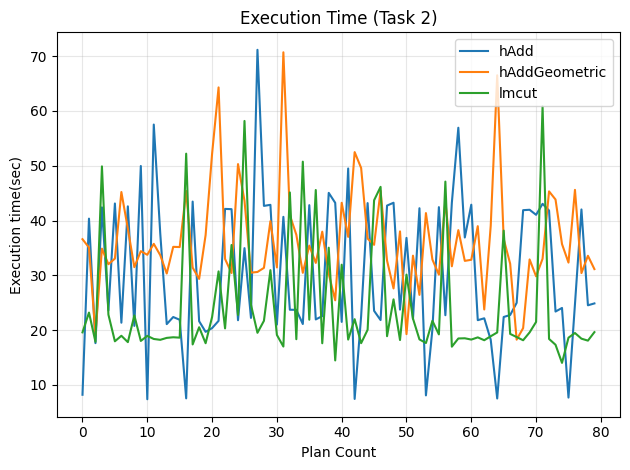

In [83]:
plt.figure()
plt.plot(exp2_hadd_execution_time, label='hAdd')
plt.plot(exp2_haddgeometric_execution_time, label='hAddGeometric')
plt.plot(exp2_lmcut_execution_time, label='lmcut')
plt.xlabel('Plan Count')
plt.ylabel('Execution time(sec)')
plt.title('Execution Time (Task 2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()